# Binary Classification with CNNs: Kaggle Data Set
With transfer learning from the pneumonia MNIST data set

## Setup

In [1]:
import numpy as np
import seaborn as sb
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

import datetime

notebook_start_time = datetime.datetime.now()

2025-05-10 21:15:40.524154: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-10 21:15:40.658097: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746926140.710586   11901 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746926140.725455   11901 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746926140.846048   11901 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
test_dir = "data/test"
train_dir = "data/train"
validation_dir = "data/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


2025-05-10 21:15:42.699745: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-05-10 21:15:43.121465: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
def confusion_matrix_two_by_two(ax, y_true, y_pred) -> None:
    cm = confusion_matrix(y_true, y_pred)
    sb.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.xaxis.set_ticklabels(
        [
            f"Normal ({(cm[0][0] + cm[1][0])/len(y_pred):.3f})",
            f"Pneumonia ({(cm[0][1] + cm[1][1])/len(y_pred):.3f})",
        ]
    )
    ax.yaxis.set_ticklabels(
        [
            f"Normal ({(cm[0][0] + cm[0][1])/len(y_pred):.3f})",
            f"Pneumonia ({(cm[1][0] + cm[1][1])/len(y_pred):.3f})",
        ]
    )
    ax.set_title("Confusion Matrix")


def summary_graphics(history, model):
    y_pred = np.round(model.predict(test_ds))
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(16, 5)
    ax = ax.flatten()

    # true/false positive/negative rates (better than accuracy for imbalanced data!)
    ax[0].plot(history.history["tp"], label="True Positives", color="g")
    # ax[0].plot(history.history['fp'], label = 'False Positives')
    ax[0].plot(history.history["tn"], label="True Negatives", color="r")
    # ax[0].plot(history.history['fn'], label = 'False Negatives', color='orange')
    ax[0].grid(True)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Metric Value")
    ax[0].legend(loc="right")
    ax[0].set_title("True Positive and True Negative Rates")

    # loss
    ax[1].plot(history.history["loss"], label="Loss")
    ax[1].plot(history.history["val_loss"], label="Val Loss")
    ax[1].grid(True)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend(loc="upper right")
    ax[1].set_title("Loss")

    # confusion matrix
    confusion_matrix_two_by_two(ax[2], y_true, y_pred)

    plt.show()

In [4]:
def get_class_training_weights(assignments, normalize=True):
    # my normal function doesn't work with the tf.data.Dataset object, so I'm writing a new one
    weight_1 = sum(assignments) / len(assignments)
    weight_0 = 1 - weight_1
    if normalize:
        denom = max(weight_1, weight_0)
        weight_1 = weight_1 / denom
        weight_0 = weight_0 / denom
    return {0: weight_0, 1: weight_1}


class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

2025-05-10 21:15:49.218852: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Weight for normal class: 0.346
Weight for pneumonia class: 1.000


## Training

In [5]:
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
transfer_model.summary()

Model: "Model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.1rflip (RandomFlip)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 889,461 (3.39 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 592,804 (2.26 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


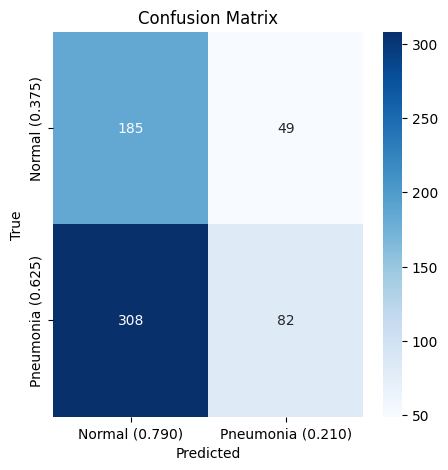

In [6]:
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(
            28, 28, name="resizing"
        ),  # mnist data set is 28 x 28 x 1
        transfer_model,
    ],
    name="Model_1",
)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

y_pred = np.round(model_1.predict(test_ds))

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)
confusion_matrix_two_by_two(ax, y_true, y_pred)

In [7]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras", save_best_only=True, monitor="val_loss", mode="min"
)

epochs = 30

history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)

Epoch 1/30


163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8104 - loss: 0.2003 - precision: 0.8089 - recall: 0.9783 - tn: 216.2439 - tp: 1936.7378 - val_accuracy: 0.5625 - val_loss: 0.7602 - val_precision: 1.0000 - val_recall: 0.1250 - val_tn: 8.0000 - val_tp: 1.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8407 - loss: 0.1629 - precision: 0.8368 - recall: 0.9770 - tn: 292.8171 - tp: 1929.1464 - val_accuracy: 0.6875 - val_loss: 0.6436 - val_precision: 0.8000 - val_recall: 0.5000 - val_tn: 7.0000 - val_tp: 4.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8422 - loss: 0.1603 - precision: 0.8385 - recall: 0.9780 - tn: 299.6707 - tp: 1929.9512 - val_accuracy: 0.5000 - val_loss: 0.8293 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8435 - loss: 0.1585 - precision: 0.8407 - recall: 0.9760 - tn: 305.1585 - tp: 1927.1525 - val_accuracy:

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


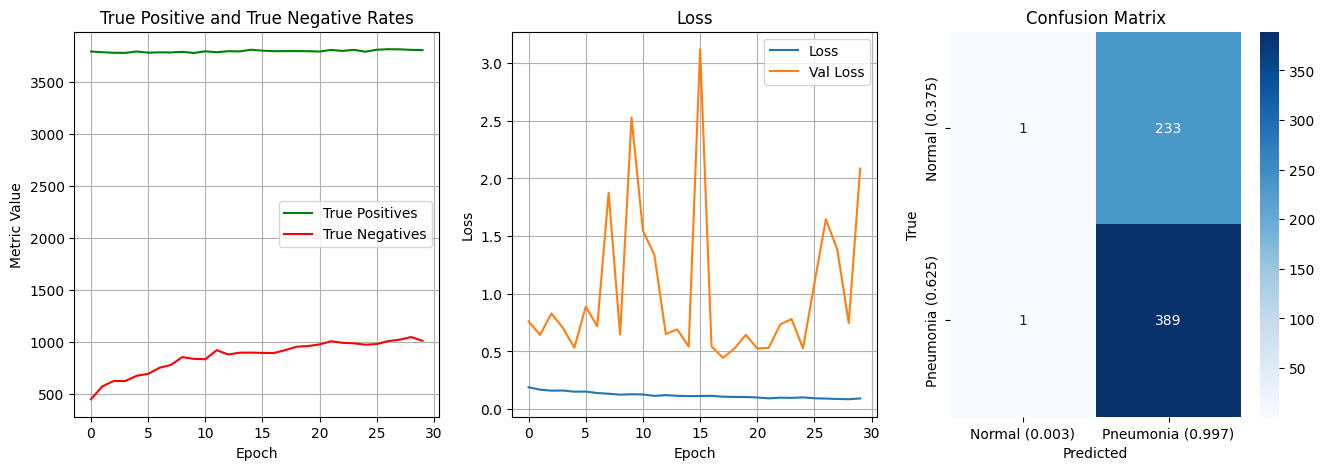

In [8]:
summary_graphics(history, model_1)

In [ ]:
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

# copy over the weights
model_2.get_layer("1.1conv").set_weights(
    transfer_model.get_layer("1.1conv").get_weights()
)
model_2.get_layer("1.2conv").set_weights(
    transfer_model.get_layer("1.2conv").get_weights()
)
model_2.get_layer("2.1conv").set_weights(
    transfer_model.get_layer("2.1conv").get_weights()
)
model_2.get_layer("2.2conv").set_weights(
    transfer_model.get_layer("2.2conv").get_weights()
)
model_2.get_layer("3.1conv").set_weights(
    transfer_model.get_layer("3.1conv").get_weights()
)
model_2.get_layer("3.3conv").set_weights(
    transfer_model.get_layer("3.3conv").get_weights()
)
model_2.get_layer("4.1conv").set_weights(
    transfer_model.get_layer("4.1conv").get_weights()
)
model_2.get_layer("4.3conv").set_weights(
    transfer_model.get_layer("4.3conv").get_weights()
)
model_2.get_layer("5.2dense").set_weights(
    transfer_model.get_layer("5.2dense").get_weights()
)
model_2.get_layer("5.4dense").set_weights(
    transfer_model.get_layer("5.4dense").get_weights()
)
# model_2.get_layer("output").set_weights(transfer_model.get_layer("output"))

model_2.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [10]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.7362 - loss: 0.2749 - precision: 0.7518 - recall: 0.9587 - tn: 76.6829 - tp: 1937.5731 - val_accuracy: 0.5000 - val_loss: 0.7049 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7991 - loss: 0.1935 - precision: 0.8013 - recall: 0.9722 - tn: 207.1890 - tp: 1920.7317 - val_accuracy: 0.5000 - val_loss: 0.7194 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8214 - loss: 0.1849 - precision: 0.8189 - recall: 0.9787 - tn: 259.0488 - tp: 1929.0244 - val_accuracy: 0.5000 - val_loss: 0.7011 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8355 - loss: 0.1656 - precision: 0.8308 - recall: 0.9792 - tn: 279.4695 - tp: 1931.67

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


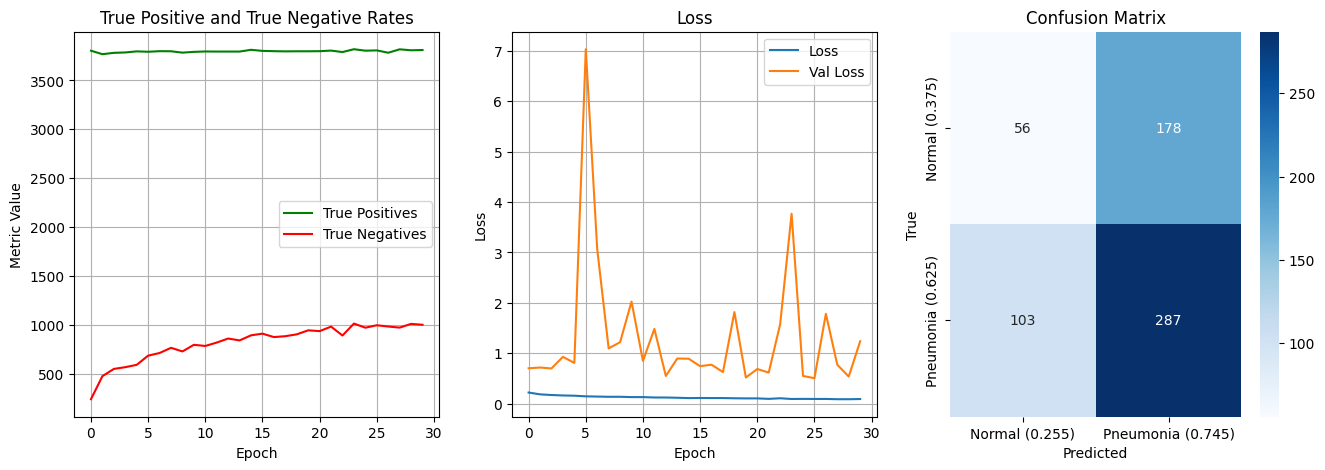

In [11]:
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# continue doing transfer learning but increase dropout in the dense layers
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
    "3.1conv",
    "3.3conv",
    "4.1conv",
    "4.3conv",
    "5.2dense",
    "5.4dense",
]

for layer_name in layer_names:
    model_3.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )

model_3.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [13]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)

Epoch 1/30


163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.7537 - loss: 0.2506 - precision: 0.7640 - recall: 0.9704 - tn: 99.4573 - tp: 1945.0061 - val_accuracy: 0.5000 - val_loss: 0.7137 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.8107 - loss: 0.1881 - precision: 0.8104 - recall: 0.9746 - tn: 212.3841 - tp: 1924.5670 - val_accuracy: 0.5000 - val_loss: 0.7202 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8150 - loss: 0.1801 - precision: 0.8115 - recall: 0.9808 - tn: 233.3232 - tp: 1930.6403 - val_accuracy: 0.6250 - val_loss: 0.6722 - val_precision: 1.0000 - val_recall: 0.2500 - val_tn: 8.0000 - val_tp: 2.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8573 - loss: 0.1671 - precision: 0.8514 - recall: 0.9803 - tn: 325.7073 - tp: 1933.8781 - val_accuracy: 0

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


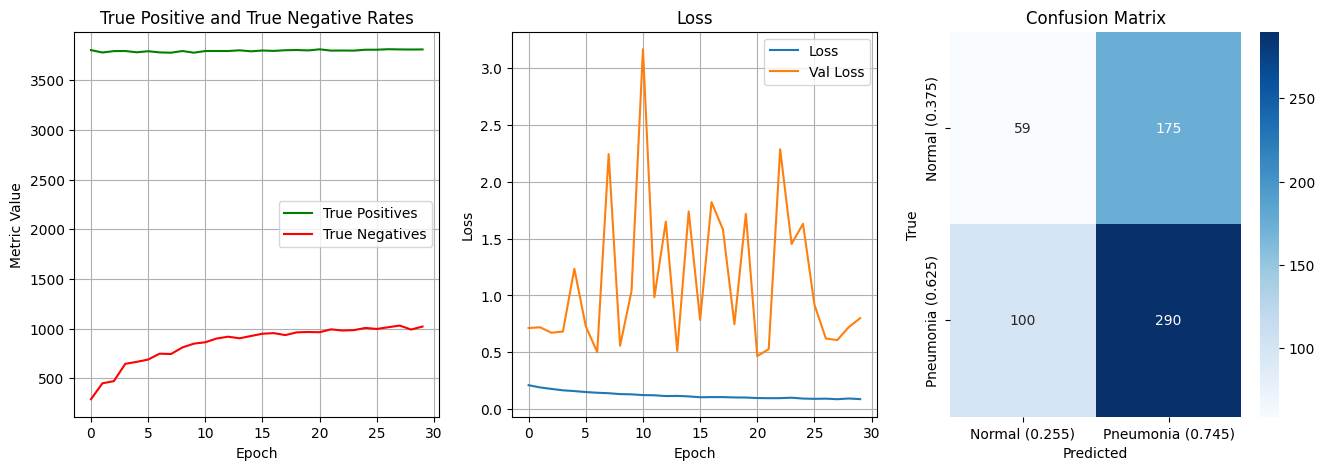

In [14]:
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# add in a small amount of dropout everywhere
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_4 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_4",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
    "3.1conv",
    "3.3conv",
    "4.1conv",
    "4.3conv",
    "5.2dense",
    "5.4dense",
]

for layer_name in layer_names:
    model_4.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )

model_4.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7561 - loss: 0.2472 - precision: 0.7581 - recall: 0.9870 - tn: 66.9146 - tp: 1959.0061 - val_accuracy: 0.5000 - val_loss: 0.6924 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.8017 - loss: 0.1960 - precision: 0.7991 - recall: 0.9822 - tn: 188.5732 - tp: 1940.7378 - val_accuracy: 0.7500 - val_loss: 0.6849 - val_precision: 0.6667 - val_recall: 1.0000 - val_tn: 4.0000 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8034 - loss: 0.2018 - precision: 0.8025 - recall: 0.9783 - tn: 211.8537 - tp: 1931.3292 - val_accuracy: 0.5000 - val_loss: 0.8023 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.8068 - loss: 0.1875 - precision: 0.8019 - recall: 0.9857 - tn: 204.2317 - tp: 1943.5670 - val_

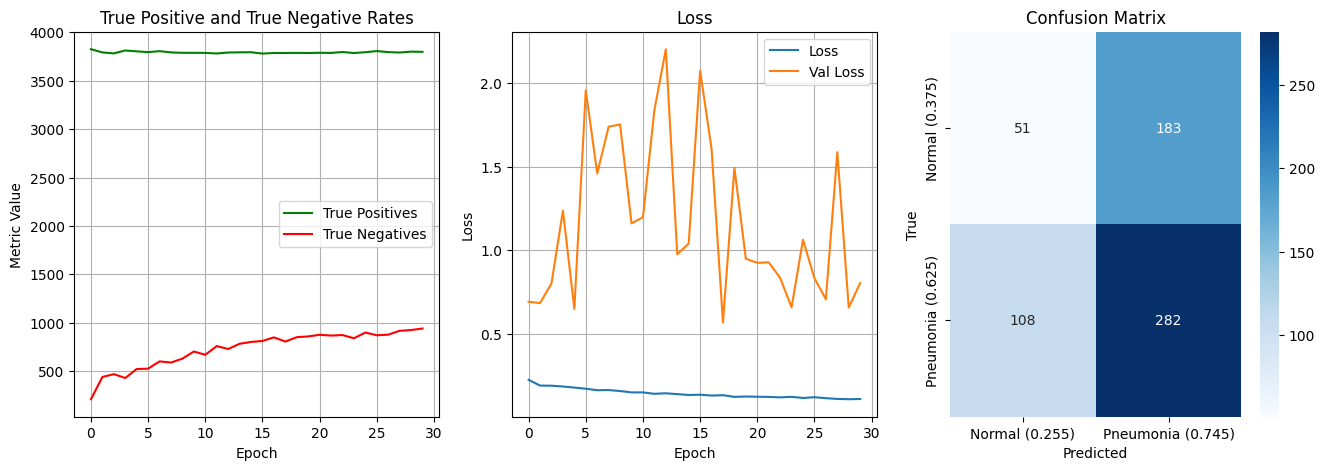

In [16]:
history = model_4.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# go back to original model, copy only early layers, and freeze them
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_5 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_5",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_5.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    model_5.get_layer(layer_name).trainable = False

model_5.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.7442 - loss: 0.2821 - precision: 0.7526 - recall: 0.9751 - tn: 67.2622 - tp: 1956.1097 - val_accuracy: 0.5000 - val_loss: 0.7491 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.8149 - loss: 0.1794 - precision: 0.8146 - recall: 0.9763 - tn: 227.8171 - tp: 1928.6830 - val_accuracy: 0.5000 - val_loss: 0.6881 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8269 - loss: 0.1682 - precision: 0.8249 - recall: 0.9754 - tn: 272.9390 - tp: 1922.4451 - val_accuracy: 0.7500 - val_loss: 0.6794 - val_precision: 1.0000 - val_recall: 0.5000 - val_tn: 8.0000 - val_tp: 4.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8430 - loss: 0.1583 - precision: 0.8413 - recall: 0.9741 - tn: 317.3232 - tp: 1918.9695 - val_acc

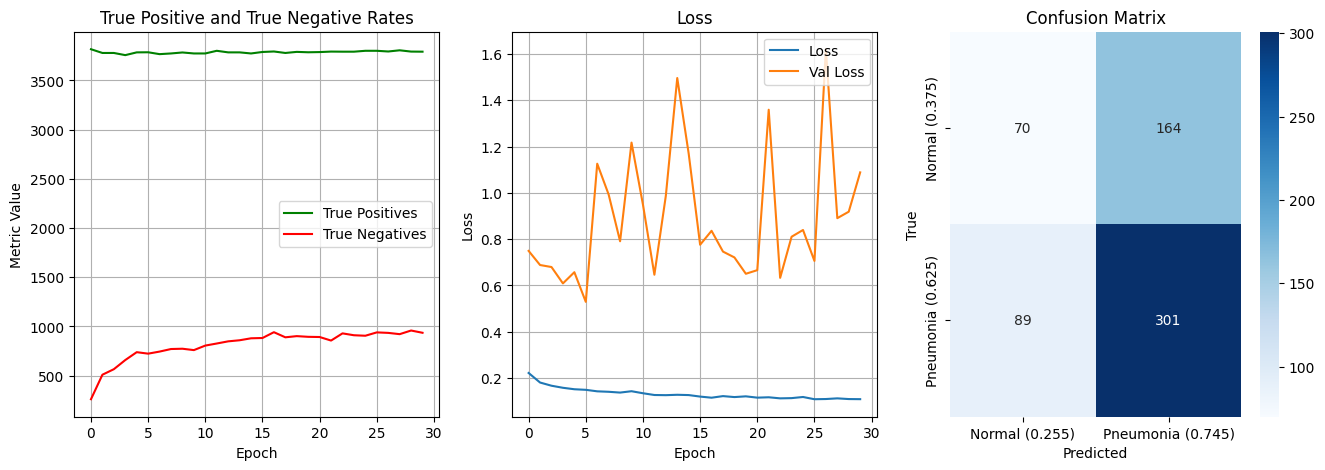

In [18]:
history = model_5.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# do something similar to model 5 but increase number of neurons in later layers
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_6 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_6",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_6.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    model_6.get_layer(layer_name).trainable = False

model_6.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7519 - loss: 0.2603 - precision: 0.7539 - recall: 0.9919 - tn: 40.2683 - tp: 1973.5305 - val_accuracy: 0.5000 - val_loss: 0.6988 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.8157 - loss: 0.1870 - precision: 0.8137 - recall: 0.9769 - tn: 229.4390 - tp: 1932.2378 - val_accuracy: 0.5000 - val_loss: 0.6923 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8273 - loss: 0.1658 - precision: 0.8243 - recall: 0.9788 - tn: 269.5427 - tp: 1930.5610 - val_accuracy: 0.5000 - val_loss: 0.6896 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8332 - loss: 0.1669 - precision: 0.8297 - recall: 0.9789 - tn: 280.2805 - tp: 1929.2

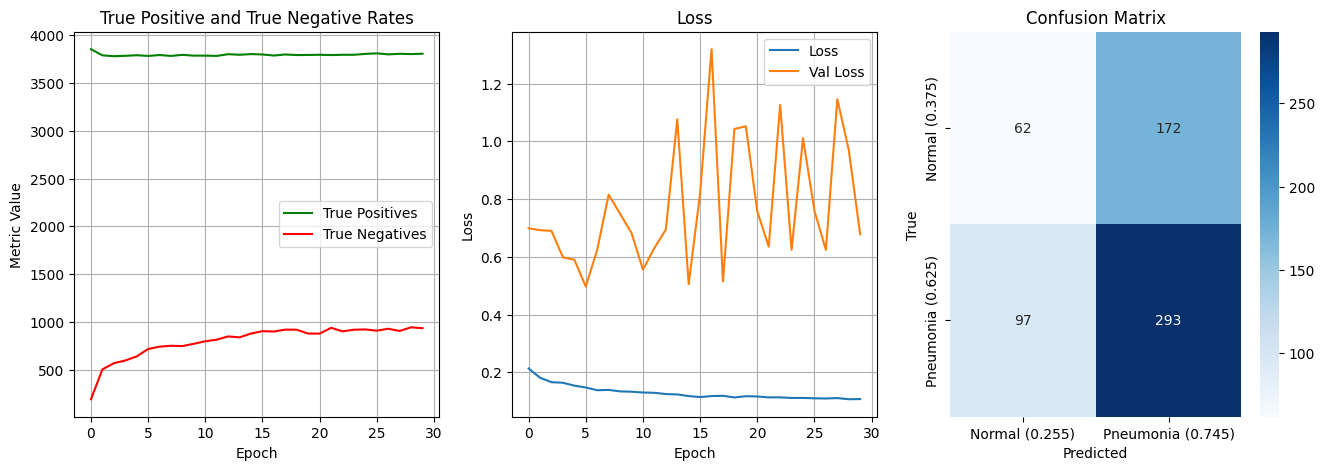

In [20]:
history = model_6.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# let's try without dropout
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_7 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        # tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        # tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_7",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_7.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    model_7.get_layer(layer_name).trainable = False

model_7.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7608 - loss: 0.2563 - precision: 0.7652 - recall: 0.9791 - tn: 107.0244 - tp: 1950.5792 - val_accuracy: 0.5000 - val_loss: 0.7464 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8115 - loss: 0.1821 - precision: 0.8091 - recall: 0.9781 - tn: 225.1219 - tp: 1930.8110 - val_accuracy: 0.5000 - val_loss: 0.7150 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8330 - loss: 0.1658 - precision: 0.8299 - recall: 0.9773 - tn: 292.6463 - tp: 1924.2317 - val_accuracy: 0.5000 - val_loss: 0.6843 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8546 - loss: 0.1553 - precision: 0.8538 - recall: 0.9725 - tn: 342.0366 - tp: 1921.71

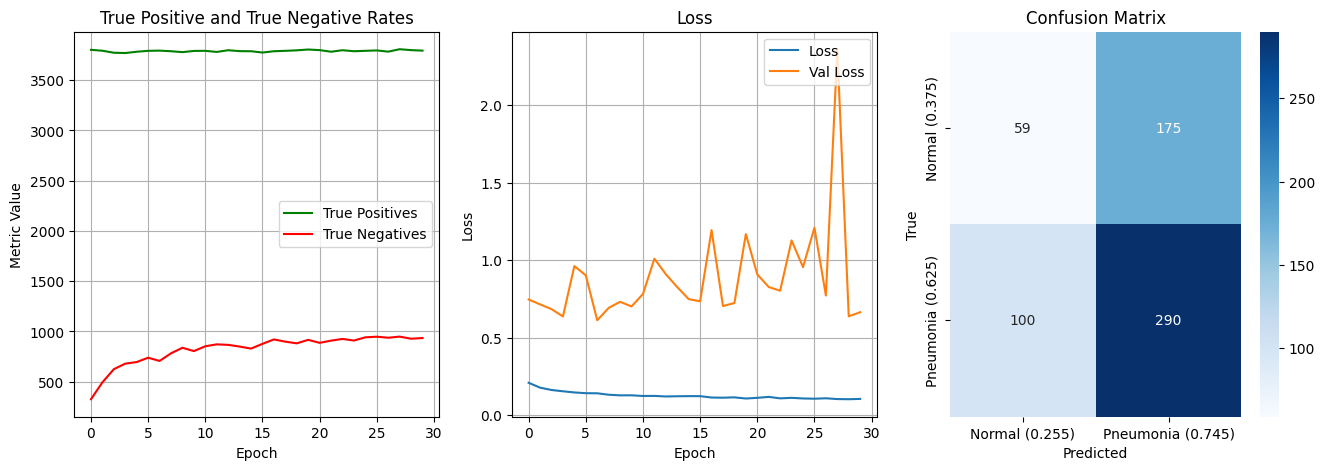

In [23]:
history = model_7.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# let's try without preprocessing and with lower learning rate
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_8 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # #tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        # tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        # tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        # tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        # tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_8",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_8.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    model_8.get_layer(layer_name).trainable = False

model_8.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4
    ),  # 1e-4 instead of default 1e-3
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7364 - loss: 0.3637 - precision: 0.7528 - recall: 0.9622 - tn: 32.2500 - tp: 1953.0061 - val_accuracy: 0.5000 - val_loss: 0.7045 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8867 - loss: 0.1232 - precision: 0.8843 - recall: 0.9763 - tn: 429.0244 - tp: 1926.6464 - val_accuracy: 0.5000 - val_loss: 0.6892 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9245 - loss: 0.0931 - precision: 0.9251 - recall: 0.9783 - tn: 514.3110 - tp: 1932.6586 - val_accuracy: 0.5625 - val_loss: 0.6672 - val_precision: 1.0000 - val_recall: 0.1250 - val_tn: 8.0000 - val_tp: 1.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.9310 - loss: 0.0822 - precision: 0.9286 - recall: 0.9845 - tn: 526.4817 - tp: 1945.213

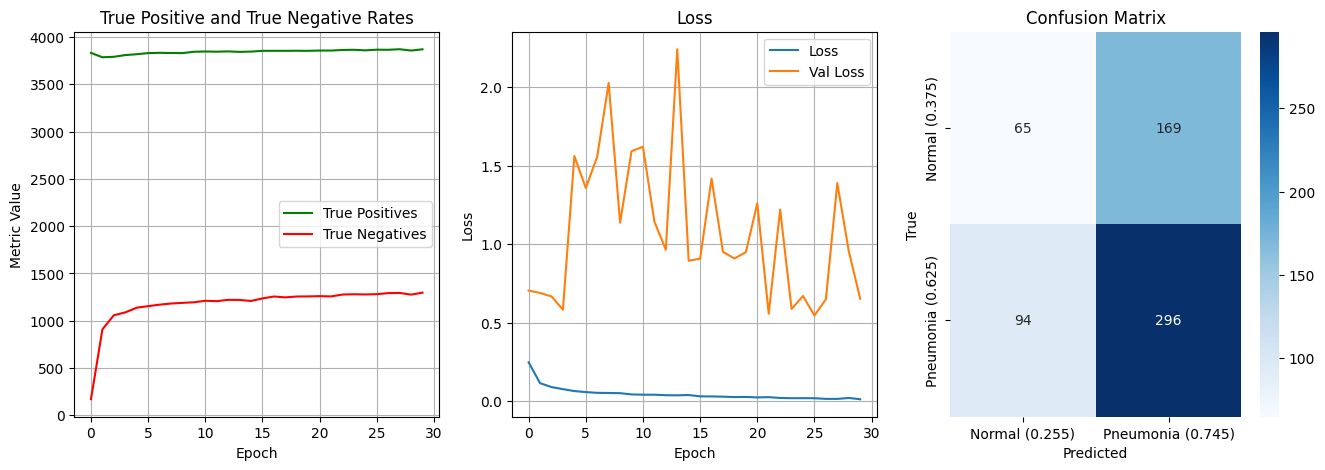

In [25]:
history = model_8.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# add the preprocessing and dropout back in and try with even lower learning rate
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_9 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_9",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_9.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    model_9.get_layer(layer_name).trainable = False

model_9.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5
    ),  # 1e-5 instead of default 1e-3
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.6712 - loss: 0.5660 - precision: 0.7612 - recall: 0.8169 - tn: 91.9329 - tp: 1771.0244 - val_accuracy: 0.5000 - val_loss: 0.6941 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7460 - loss: 0.4220 - precision: 0.7460 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1974.0366 - val_accuracy: 0.5000 - val_loss: 0.7156 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7473 - loss: 0.2862 - precision: 0.7473 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1973.5122 - val_accuracy: 0.5000 - val_loss: 0.7560 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.7478 - loss: 0.2759 - precision: 0.7478 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1972.9

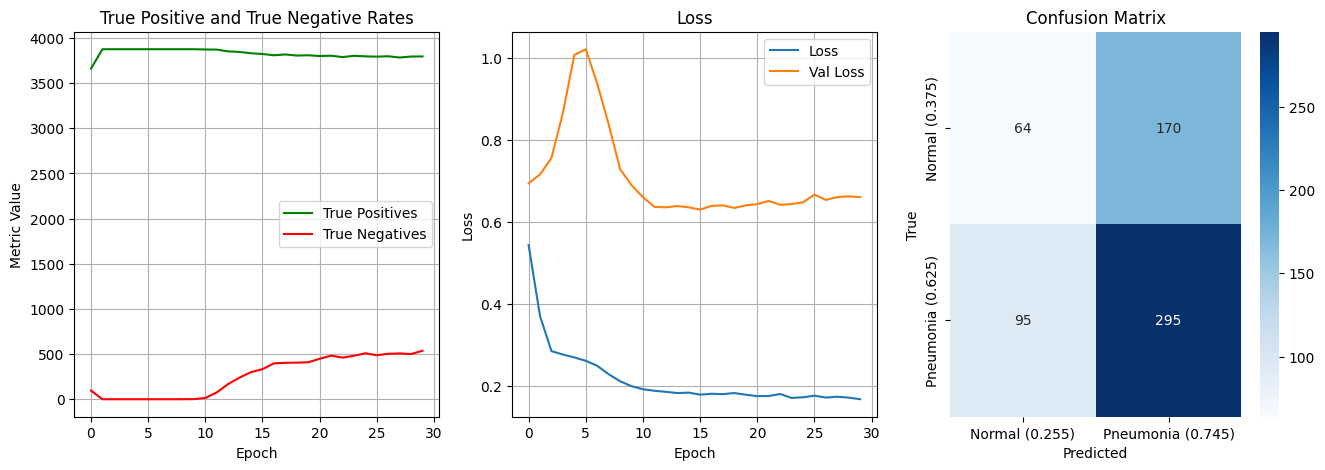

In [27]:
history = model_9.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# try with learning rate not as low, and unfreeze the transferred layers
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_10 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_10",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_10.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    # model_9.get_layer(layer_name).trainable = False

model_10.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7348 - loss: 0.3912 - precision: 0.7460 - recall: 0.9724 - tn: 11.9695 - tp: 1961.7439 - val_accuracy: 0.5000 - val_loss: 0.7191 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7495 - loss: 0.2012 - precision: 0.7493 - recall: 0.9996 - tn: 8.2012 - tp: 1973.1036 - val_accuracy: 0.5000 - val_loss: 0.7126 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7965 - loss: 0.1821 - precision: 0.7924 - recall: 0.9875 - tn: 173.5610 - tp: 1945.6586 - val_accuracy: 0.5000 - val_loss: 0.6539 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8270 - loss: 0.1716 - precision: 0.8204 - recall: 0.9835 - tn: 254.2744 - tp: 1938.6158 - val_ac

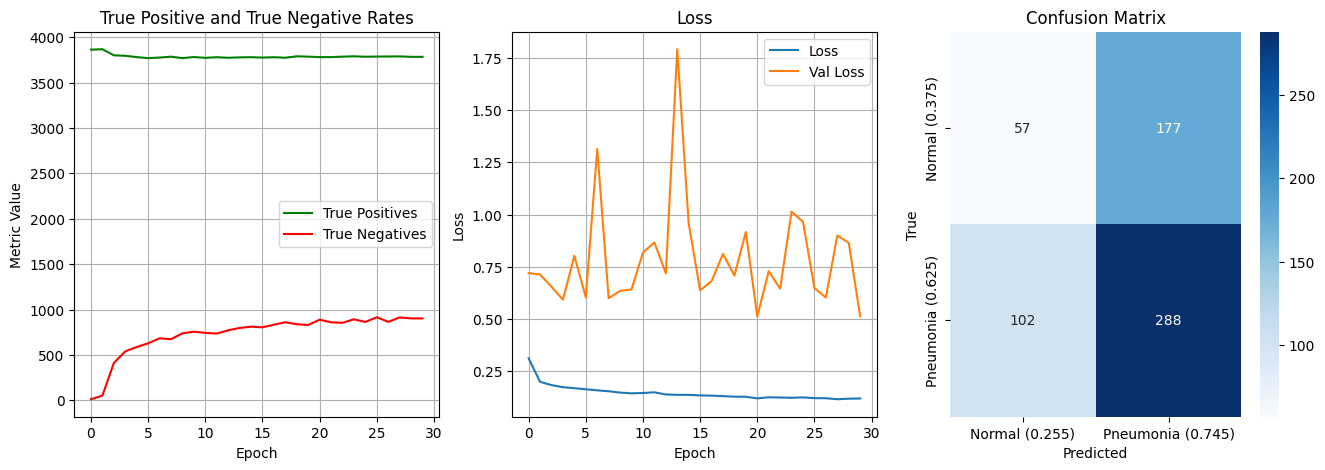

In [30]:
history = model_10.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# try with lower dropout
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_11 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.3, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.3, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_11",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_11.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    # model_9.get_layer(layer_name).trainable = False

model_11.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7327 - loss: 0.3867 - precision: 0.7463 - recall: 0.9674 - tn: 13.9878 - tp: 1954.4878 - val_accuracy: 0.5000 - val_loss: 0.7114 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7544 - loss: 0.2143 - precision: 0.7535 - recall: 0.9986 - tn: 30.0366 - tp: 1968.1951 - val_accuracy: 0.5000 - val_loss: 0.6874 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7935 - loss: 0.1963 - precision: 0.7885 - recall: 0.9879 - tn: 169.1219 - tp: 1946.4695 - val_accuracy: 0.5000 - val_loss: 0.6897 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8153 - loss: 0.1832 - precision: 0.8124 - recall: 0.9806 - tn: 226.3049 - tp: 1937.5853

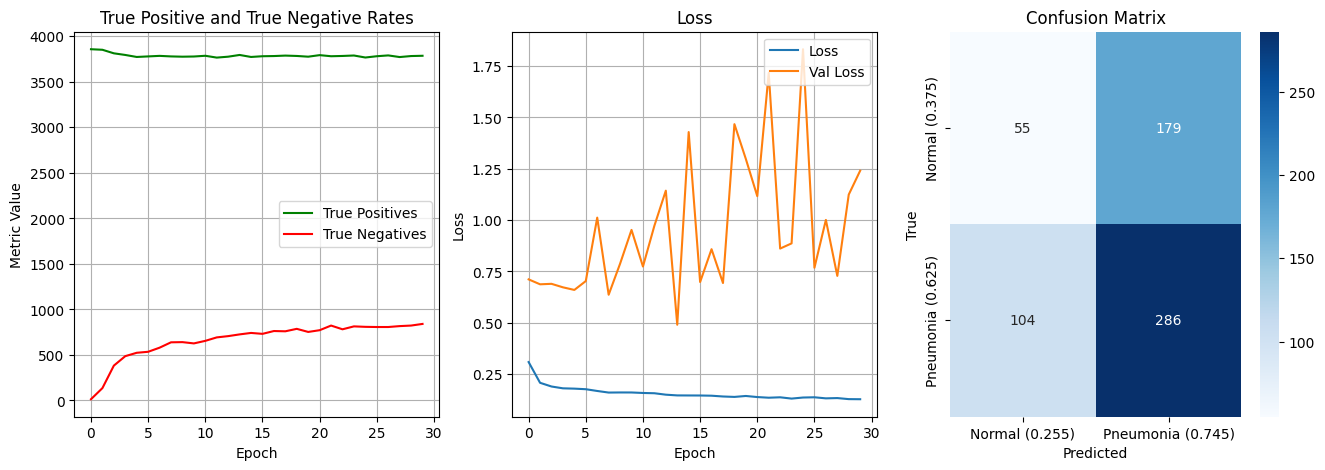

In [32]:
history = model_11.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# try with a learning rate between 1e-4 and 1e-5
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_12 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.3, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.3, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_12",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_12.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    # model_9.get_layer(layer_name).trainable = False

model_12.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=(1e-4) / 2),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7352 - loss: 0.4378 - precision: 0.7481 - recall: 0.9660 - tn: 17.9512 - tp: 1957.0610 - val_accuracy: 0.5000 - val_loss: 0.7136 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7473 - loss: 0.2463 - precision: 0.7473 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1972.2866 - val_accuracy: 0.5000 - val_loss: 0.7086 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7537 - loss: 0.2047 - precision: 0.7527 - recall: 0.9992 - tn: 25.7500 - tp: 1970.3781 - val_accuracy: 0.5000 - val_loss: 0.6748 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7819 - loss: 0.1932 - precision: 0.7781 - recall: 0.9920 - tn: 114.0732 - tp: 1955.6769 - val

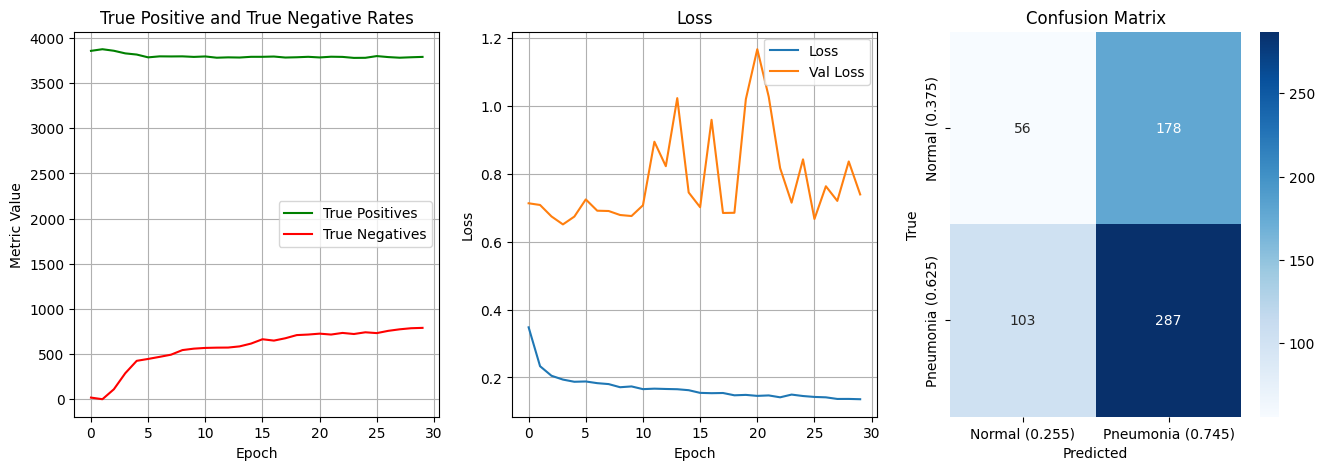

In [34]:
history = model_12.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [ ]:
# try with 0.5 dropout everywhere
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_13 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="rescaling"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_13",
)

# copy over the weights
layer_names = [
    "1.1conv",
    "1.2conv",
    "2.1conv",
    "2.2conv",
]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_13.get_layer(layer_name).set_weights(
        transfer_model.get_layer(layer_name).get_weights()
    )
    # model_9.get_layer(layer_name).trainable = False

model_13.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=(1e-4) / 2),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7073 - loss: 0.3776 - precision: 0.7411 - recall: 0.9235 - tn: 25.5610 - tp: 1911.9695 - val_accuracy: 0.5000 - val_loss: 0.6954 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7454 - loss: 0.2871 - precision: 0.7454 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1971.5914 - val_accuracy: 0.5000 - val_loss: 0.7020 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7484 - loss: 0.2842 - precision: 0.7484 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1973.4025 - val_accuracy: 0.5000 - val_loss: 0.7278 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7479 - loss: 0.2825 - precision: 0.7479 - recall: 1.0000 - tn: 0.0000e+00 - tp: 1976.1769 

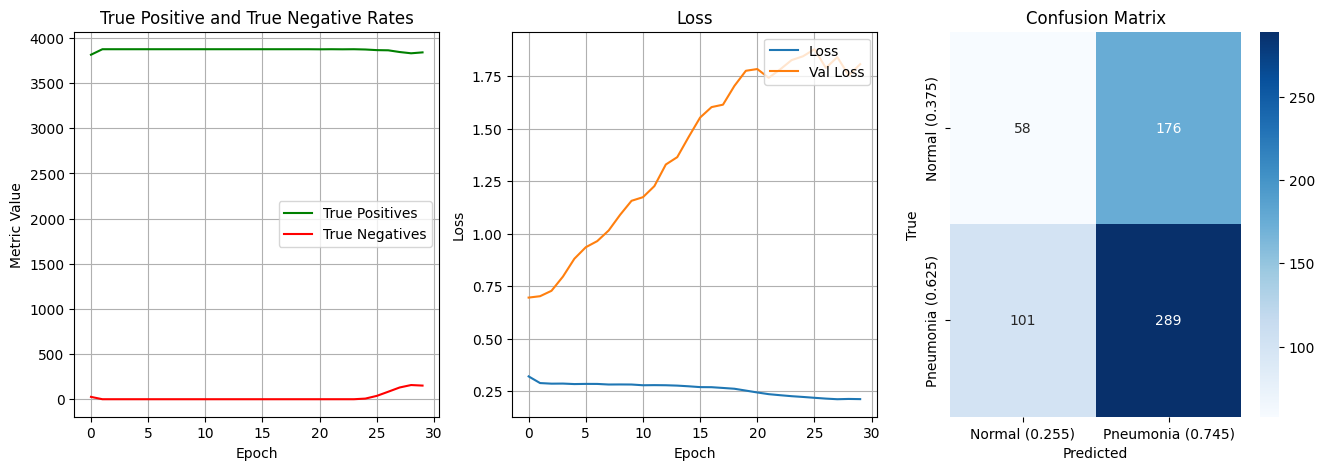

In [36]:
history = model_13.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback],
)
best_model = tf.keras.models.load_model("best_model.keras")
summary_graphics(history, best_model)

In [21]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2025-05-10 21:40:34.052308 (duration: 0:24:51.588144)
